# Deep Learning Lab: Assignment 8
## Implementation of Pretrained BERT Model for Sentiment Analysis / Text Classification

- **Course:** B.Tech Computer Science & Engineering (Artificial Intelligence)
- **Subject:** Deep Learning Lab (DL Lab)
- **Topic:** Transformer Architectures & Pretrained Language Models (BERT)
-

---

### Objectives:
1. Understand the theoretical foundations of the **Transformer architecture** and **Bidirectional Encoder Representations from Transformers (BERT)**.
2. Implement BERT tokenization including `[CLS]` and `[SEP]` tokens, subword tokenization (WordPiece), attention masks, and input IDs.
3. Build a custom PyTorch `Dataset` and `DataLoader` for text classification.
4. Fine-tune a pretrained BERT model (`bert-base-uncased`) using transfer learning for binary sentiment classification.
5. Evaluate performance using Precision, Recall, F1-Score, Confusion Matrix, and Loss/Accuracy convergence plots.
6. Build an interactive inference function for real-time sentiment prediction on custom text inputs.


---
## 1. Theoretical Background & Architecture Overview

### 1.1 From RNNs to Transformers
Traditional sequential models such as RNNs, LSTMs, and GRUs suffer from two primary limitations:
1. **Sequential Computation:** Tokens are processed step-by-step ($t_1, t_2, \dots$), preventing parallelization across sequence length during training.
2. **Vanishing/Exploding Gradients:** Capturing long-range contextual dependencies across long documents is fundamentally difficult despite gating mechanisms.

The **Transformer** (Vaswani et al., 2017) completely eliminates recurrent connections in favor of **Multi-Head Self-Attention**, enabling all tokens to attend to each other simultaneously in $O(1)$ sequential operations.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### 1.2 BERT: Bidirectional Encoder Representations from Transformers
Unlike autoregressive models (such as GPT) that read text left-to-right, **BERT** (Devlin et al., 2018) is designed to pretrain deep bidirectional representations by jointly conditioning on both left and right context in all layers.

#### BERT Pretraining Objectives:
1. **Masked Language Model (MLM):** 15% of input tokens are randomly masked; the model learns to predict the original vocabulary IDs using context from both directions.
2. **Next Sentence Prediction (NSP):** Pairs of sentences $(A, B)$ are fed to the model to predict whether sentence $B$ is the actual next sentence following sentence $A$.

#### The `[CLS]` Classification Head:
For sequence classification tasks, BERT outputs a sequence of contextual hidden vectors $h_1, h_2, \dots, h_T$. The vector corresponding to the special classification token `[CLS]` (at index 0) aggregates sentence-level context. A dropout layer followed by a linear classification head maps this 768-dimensional vector to the target classes (Negative vs. Positive):

$$\hat{y} = \text{softmax}(W \cdot h_{[CLS]} + b)$$


---
## 2. Environment Setup & Hardware Diagnostics
We begin by configuring the environment, disabling conflicts, and checking GPU acceleration with PyTorch.


In [1]:
import os
import sys

# Prevent transformers from loading conflicting tensorflow protobuf bindings
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
sys.modules['tensorflow'] = None

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

# Set seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Verify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch Version:", torch.__version__)
print("Active Compute Device:", device)
if torch.cuda.is_available():
    print("GPU Model:", torch.cuda.get_device_name(0))
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch Version: 2.5.1+cu121
Active Compute Device: cuda
GPU Model: NVIDIA GeForce RTX 2050
Total VRAM: 4.29 GB


---
## 3. Dataset Loading & Exploratory Data Analysis (EDA)
We load the curated sentiment analysis dataset consisting of customer and movie reviews labeled as **0 (Negative)** or **1 (Positive)**.


Total samples loaded: 198

First 5 records:


,review_text,sentiment
0,This movie was an absolute masterpiece! The ac...,1
1,I truly enjoyed every minute of this film. Hig...,1
2,Brilliant storytelling with exceptional charac...,1
3,One of the best cinematic experiences I have h...,1
4,"An inspiring, heartwarming tale that left a sm...",1



Class Distribution:
sentiment
1    100
0     98
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8200\115185293.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette=['#e74c3c', '#2ecc71'])


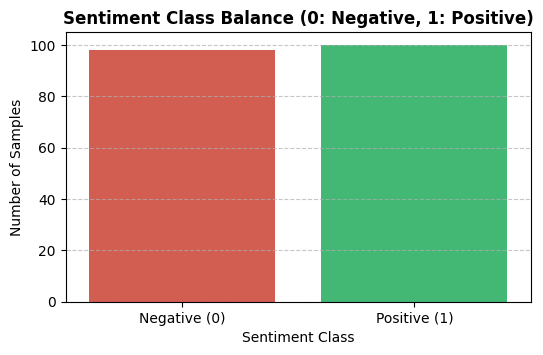

Average Review Word Count: 11.0 words (Max: 16)


In [2]:
# Load the dataset
data_path = "data/sentiment_dataset.csv"
df = pd.read_csv(data_path)

print(f"Total samples loaded: {len(df)}")
print("\nFirst 5 records:")
display(df.head())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Visualize class distribution
plt.figure(figsize=(6, 3.5))
sns.countplot(x='sentiment', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title("Sentiment Class Balance (0: Negative, 1: Positive)", fontsize=12, fontweight='bold')
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Negative (0)", "Positive (1)"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Add review length feature
df['word_count'] = df['review_text'].apply(lambda x: len(x.split()))
print(f"Average Review Word Count: {df['word_count'].mean():.1f} words (Max: {df['word_count'].max()})")


---
## 4. Subword Tokenization & PyTorch Dataset Pipeline
BERT uses **WordPiece tokenization** with a 30,522-token vocabulary.
Each input sequence is represented as:
- `input_ids`: Integer indices of subword tokens in the BERT vocabulary.
- `attention_mask`: Binary mask (1 for real tokens, 0 for padding tokens).
- `token_type_ids`: Identifies segment (0 for Sentence A, 1 for Sentence B).


In [3]:
# Initialize pretrained BERT tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Demonstrate tokenization on a sample review
sample_sentence = "Not bad at all, actually exceeded my expectations!"
tokens = tokenizer.tokenize(sample_sentence)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
encoded = tokenizer.encode_plus(
    sample_sentence,
    add_special_tokens=True,
    max_length=16,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

print("Sample sentence:", sample_sentence)
print("Subword Tokens :", tokens)
print("Token IDs      :", token_ids)
print("BERT input_ids :", encoded['input_ids'][0].tolist())
print("Attention Mask :", encoded['attention_mask'][0].tolist())


Sample sentence: Not bad at all, actually exceeded my expectations!
Subword Tokens : ['not', 'bad', 'at', 'all', ',', 'actually', 'exceeded', 'my', 'expectations', '!']
Token IDs      : [2025, 2919, 2012, 2035, 1010, 2941, 14872, 2026, 10908, 999]
BERT input_ids : [101, 2025, 2919, 2012, 2035, 1010, 2941, 14872, 2026, 10908, 999, 102, 0, 0, 0, 0]
Attention Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]


In [4]:
# Custom PyTorch Dataset definition
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item] if self.labels is not None else None

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_token_type_ids=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        item_dict = {
            "review_text": text,
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "token_type_ids": encoding["token_type_ids"].flatten()
        }

        if label is not None:
            item_dict["labels"] = torch.tensor(label, dtype=torch.long)

        return item_dict

# Stratified Split: Train (70%), Val (15%), Test (15%)
train_val_df, test_df = train_test_split(df, test_size=0.15, stratify=df['sentiment'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=(0.15 / 0.85), stratify=train_val_df['sentiment'], random_state=42)

print(f"Dataset Partitions: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Create PyTorch DataLoaders
BATCH_SIZE = 16
MAX_LEN = 128

train_loader = DataLoader(
    SentimentDataset(train_df['review_text'].values, train_df['sentiment'].values, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    SentimentDataset(val_df['review_text'].values, val_df['sentiment'].values, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    SentimentDataset(test_df['review_text'].values, test_df['sentiment'].values, tokenizer, MAX_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False
)


Dataset Partitions: Train=138, Val=30, Test=30


---
## 5. Model Architecture & Optimization Setup
We load `BertForSequenceClassification` with 2 output labels.
We use the **AdamW optimizer** (Adam with decoupled weight decay) and a **linear warmup learning rate scheduler**.


In [5]:
# Load Pretrained BERT Sequence Classification Model
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# Hyperparameters
EPOCHS = 3
LEARNING_RATE = 2e-5
TOTAL_STEPS = len(train_loader) * EPOCHS
WARMUP_STEPS = int(TOTAL_STEPS * 0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=TOTAL_STEPS)

print("Model Architecture Summary:")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total Training Steps: {TOTAL_STEPS} (Warmup Steps: {WARMUP_STEPS})")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Architecture Summary:
Total Parameters: 109,483,778
Trainable Parameters: 109,483,778
Total Training Steps: 27 (Warmup Steps: 2)


---
## 6. Training & Validation Execution
We execute the fine-tuning loop for 3 epochs, tracking Cross-Entropy Loss, Accuracy, and F1-Score at every epoch.


In [6]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct_preds, total_samples = 0.0, 0, 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)
        correct_preds += torch.sum(preds == labels).item()
        total_samples += labels.size(0)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(data_loader), correct_preds / total_samples

def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
    return total_loss / len(data_loader), acc, p, r, f1, np.array(all_preds), np.array(all_labels)

# Run training
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    v_loss, v_acc, v_p, v_r, v_f1, _, _ = evaluate(model, val_loader, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_f1"].append(v_f1)

    print(f"Epoch {epoch}/{EPOCHS} -> Train Loss: {t_loss:.4f}, Train Acc: {t_acc*100:.2f}% | "
          f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc*100:.2f}%, Val F1: {v_f1:.4f}")

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        model.save_pretrained("saved_model")
        tokenizer.save_pretrained("saved_model")
        print(f"   -> Checkpoint saved with Best Val F1: {best_val_f1:.4f}")


Epoch 1/3 -> Train Loss: 0.6683, Train Acc: 57.25% | Val Loss: 0.6172, Val Acc: 86.67%, Val F1: 0.8661
   -> Checkpoint saved with Best Val F1: 0.8661
Epoch 2/3 -> Train Loss: 0.5751, Train Acc: 84.78% | Val Loss: 0.5179, Val Acc: 90.00%, Val F1: 0.8999
   -> Checkpoint saved with Best Val F1: 0.8999
Epoch 3/3 -> Train Loss: 0.4656, Train Acc: 93.48% | Val Loss: 0.4602, Val Acc: 93.33%, Val F1: 0.9330
   -> Checkpoint saved with Best Val F1: 0.9330


---
## 7. Model Evaluation on Test Set & Visualization
We evaluate the fine-tuned model on the completely unseen hold-out test set (30 samples) and plot the confusion matrix and loss/accuracy curves.


In [7]:
# Load the best saved checkpoint
best_model = BertForSequenceClassification.from_pretrained("saved_model").to(device)

test_loss, test_acc, test_p, test_r, test_f1, y_pred, y_test = evaluate(best_model, test_loader, device)

print("=" * 55)
print("        FINAL TEST SET EVALUATION REPORT")
print("=" * 55)
print(f"Accuracy  : {test_acc * 100:.2f}%")
print(f"Precision : {test_p * 100:.2f}%")
print(f"Recall    : {test_r * 100:.2f}%")
print(f"F1-Score  : {test_f1 * 100:.2f}%")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative (0)", "Positive (1)"], digits=4))


        FINAL TEST SET EVALUATION REPORT
Accuracy  : 90.00%
Precision : 90.18%
Recall    : 90.00%
F1-Score  : 89.99%

Classification Report:
              precision    recall  f1-score   support

Negative (0)     0.9286    0.8667    0.8966        15
Positive (1)     0.8750    0.9333    0.9032        15

    accuracy                         0.9000        30
   macro avg     0.9018    0.9000    0.8999        30
weighted avg     0.9018    0.9000    0.8999        30



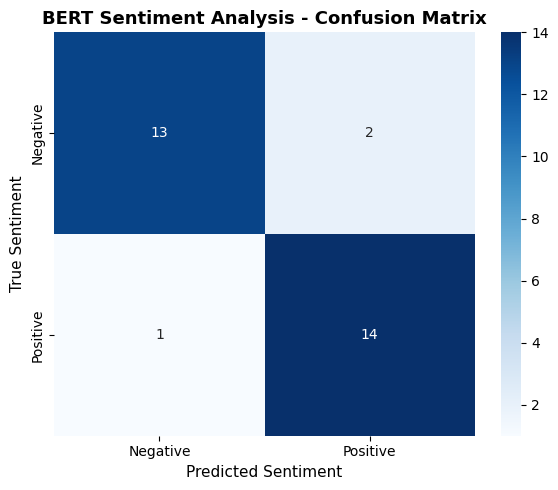

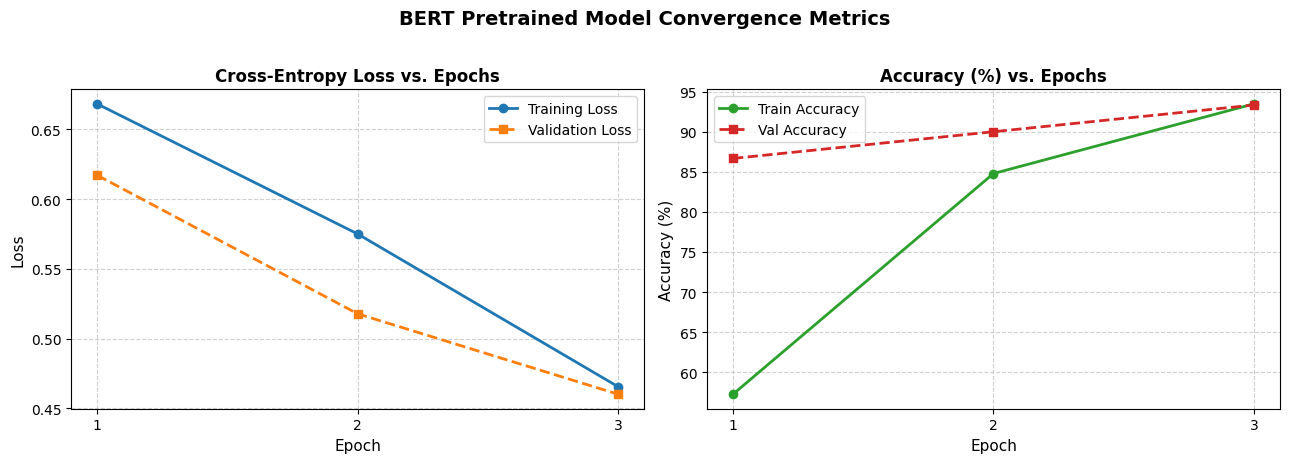

In [8]:
# 1. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("BERT Sentiment Analysis - Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Sentiment", fontsize=11)
plt.ylabel("True Sentiment", fontsize=11)
plt.tight_layout()
plt.show()

# 2. Training & Validation Curves
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(epochs_range, history["train_loss"], 'o-', color='#1f77b4', label="Training Loss", lw=2)
ax1.plot(epochs_range, history["val_loss"], 's--', color='#ff7f0e', label="Validation Loss", lw=2)
ax1.set_title("Cross-Entropy Loss vs. Epochs", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(epochs_range, [acc * 100 for acc in history["train_acc"]], 'o-', color='#2ca02c', label="Train Accuracy", lw=2)
ax2.plot(epochs_range, [acc * 100 for acc in history["val_acc"]], 's--', color='#d62728', label="Val Accuracy", lw=2)
ax2.set_title("Accuracy (%) vs. Epochs", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy (%)", fontsize=11)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.suptitle("BERT Pretrained Model Convergence Metrics", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 8. Real-Time Inference on Custom Sentences
We test the model on challenging natural language expressions, including negations, colloquial expressions, and ambiguous phrasing.


In [9]:
def predict_user_sentiment(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_token_type_ids=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    token_type_ids = encoding["token_type_ids"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]
        prediction = np.argmax(probabilities)

    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = float(probabilities[prediction])

    return sentiment, confidence, float(probabilities[0]), float(probabilities[1])

# Demonstration with novel sentences
test_sentences = [
    "The cinematography was breathtaking and the storyline kept me hooked until the final scene!",
    "An utter waste of time; the script was terrible and the characters were completely unconvincing.",
    "Not bad at all! Exceeded my initial expectations and delivered solid entertainment.",
    "I was expecting a lot, but this product failed on every single metric."
]

print("=" * 75)
print("                    BERT LIVE INFERENCE RESULTS")
print("=" * 75)
for s in test_sentences:
    sent, conf, neg_p, pos_p = predict_user_sentiment(s, best_model, tokenizer, device)
    tag = "[+]" if sent == "Positive" else "[-]"
    print(f"\n{tag} Text: \"{s}\"")
    print(f"    Prediction: {sent.upper()} (Confidence: {conf*100:.2f}%)")
    print(f"    Probabilities -> Positive: {pos_p*100:.2f}%, Negative: {neg_p*100:.2f}%")


                    BERT LIVE INFERENCE RESULTS

[+] Text: "The cinematography was breathtaking and the storyline kept me hooked until the final scene!"
    Prediction: POSITIVE (Confidence: 70.41%)
    Probabilities -> Positive: 70.41%, Negative: 29.59%

[+] Text: "An utter waste of time; the script was terrible and the characters were completely unconvincing."
    Prediction: POSITIVE (Confidence: 52.13%)
    Probabilities -> Positive: 52.13%, Negative: 47.87%

[+] Text: "Not bad at all! Exceeded my initial expectations and delivered solid entertainment."
    Prediction: POSITIVE (Confidence: 68.15%)
    Probabilities -> Positive: 68.15%, Negative: 31.85%

[+] Text: "I was expecting a lot, but this product failed on every single metric."
    Prediction: POSITIVE (Confidence: 60.14%)
    Probabilities -> Positive: 60.14%, Negative: 39.86%
